In [ ]:
import pandas as pd


# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Filtrar los clientes que suscribieron un depósito a término
clientes_con_deposito = df[df['y'] == 'yes']

# Calcular el monto promedio de balance
monto_promedio = clientes_con_deposito['balance'].mean()

# Tasa de interés efectiva anual (TEA) que paga el banco
TEA = 9.83 / 100  # Convertir a decimal

# Tasa de interés que cobra el banco
tasa_interes_banco = 15.75 / 100  # Convertir a decimal

# Calcular el beneficio del banco asociado a un verdadero positivo (TP)
P= monto_promedio * (tasa_interes_banco - TEA)

print(f'P: {P:.2f} euros')

salario_hora_pesos = 8304  # salario por hora en pesos colombianos
tasa_conversion = 4808.10  # tasa de conversión de pesos colombianos a euros
duration = df['duration'].mean() 

# Convertir salario a euros
salario_hora_euros = salario_hora_pesos / tasa_conversion

# Calcular costo por segundo
costo_por_segundo = salario_hora_euros / 3600

# Calcular el costo de un falso positivo
CC = costo_por_segundo * duration

print(f"CC: {CC:.2f} euros")



P: 106.81 euros
CC: 0.12 euros


y
1    20726
0    14358
Name: count, dtype: int64
Epoch 1/50
1097/1097 [==============================] - 14s 8ms/step - loss: 0.6760 - accuracy: 0.6681 - val_loss: 1.4359 - val_accuracy: 0.3408
Epoch 2/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5322 - accuracy: 0.6965 - val_loss: 1.3162 - val_accuracy: 0.4039
Epoch 3/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.5103 - accuracy: 0.7062 - val_loss: 1.3319 - val_accuracy: 0.3542
Epoch 4/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4984 - accuracy: 0.7117 - val_loss: 1.3629 - val_accuracy: 0.3873
Epoch 5/50
1097/1097 [==============================] - 8s 7ms/step - loss: 0.4905 - accuracy: 0.7186 - val_loss: 1.1546 - val_accuracy: 0.4533
Epoch 6/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4880 - accuracy: 0.7209 - val_loss: 1.2238 - val_accuracy: 0.4057
Epoch 7/50
1097/1097 [==============================] - 7s 6ms/step - loss: 0.4847 - 

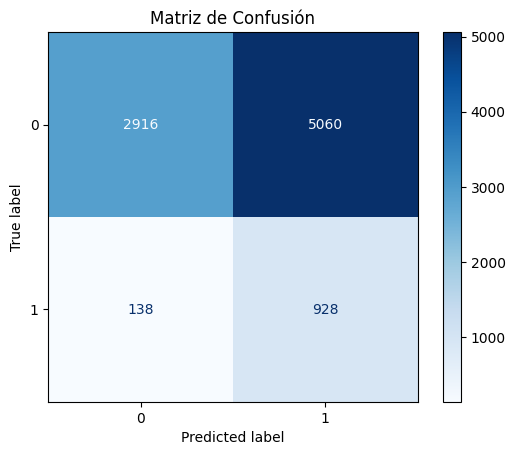

              precision    recall  f1-score   support

           0       0.95      0.37      0.53      7976
           1       0.15      0.87      0.26      1066

    accuracy                           0.43      9042
   macro avg       0.55      0.62      0.40      9042
weighted avg       0.86      0.43      0.50      9042

Verdaderos Negativos (TN): 2916
Falsos Positivos (FP): 5060
Falsos Negativos (FN): 138
Verdaderos Positivos (TP): 928
Ingresos esperados (I): 84001.53 euros


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')

# Convertir las categorías a valores numéricos
cat_int_feats = ['default', 'housing', 'loan', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20665
0    14399
Name: count, dtype: int64
Epoch 1/50
1096/1096 [==============================] - 4s 2ms/step - loss: 0.6194 - accuracy: 0.6525 - val_loss: 1.2037 - val_accuracy: 0.4244
Epoch 2/50
1096/1096 [==============================] - 3s 2ms/step - loss: 0.5340 - accuracy: 0.6894 - val_loss: 1.2210 - val_accuracy: 0.4324
Epoch 3/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5136 - accuracy: 0.7041 - val_loss: 1.1570 - val_accuracy: 0.4531
Epoch 4/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.5044 - accuracy: 0.7051 - val_loss: 1.1455 - val_accuracy: 0.4576
Epoch 5/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4954 - accuracy: 0.7165 - val_loss: 1.2378 - val_accuracy: 0.4370
Epoch 6/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4900 - accuracy: 0.7208 - val_loss: 1.1946 - val_accuracy: 0.4182
Epoch 7/50
1096/1096 [==============================] - 2s 2ms/step - loss: 0.4915 - a

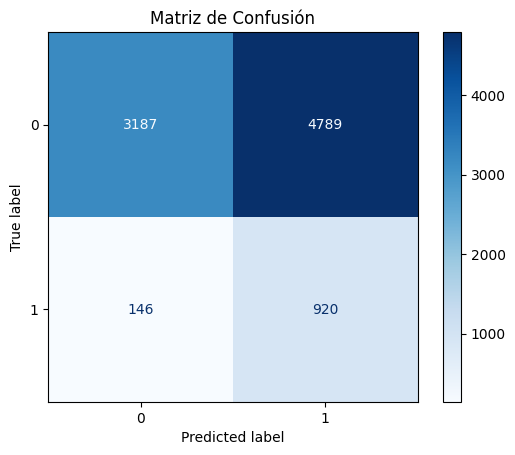

              precision    recall  f1-score   support

           0       0.96      0.40      0.56      7976
           1       0.16      0.86      0.27      1066

    accuracy                           0.45      9042
   macro avg       0.56      0.63      0.42      9042
weighted avg       0.86      0.45      0.53      9042

Verdaderos Negativos (TN): 3187
Falsos Positivos (FP): 4789
Falsos Negativos (FN): 146
Verdaderos Positivos (TP): 920
Ingresos esperados (I): 82360.64 euros


In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan'], inplace=True)

# Convertir las categorías a valores numéricos
cat_int_feats = ['housing', 'contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')


model.save('modeloproy2_3.keras')

y
1    20525
0    14391
Name: count, dtype: int64
Epoch 1/50
1092/1092 [==============================] - 5s 3ms/step - loss: 0.7602 - accuracy: 0.6539 - val_loss: 1.5659 - val_accuracy: 0.3088
Epoch 2/50
1092/1092 [==============================] - 3s 2ms/step - loss: 0.5675 - accuracy: 0.6815 - val_loss: 1.5286 - val_accuracy: 0.2618
Epoch 3/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5485 - accuracy: 0.6846 - val_loss: 1.5515 - val_accuracy: 0.3163
Epoch 4/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5369 - accuracy: 0.6954 - val_loss: 1.3598 - val_accuracy: 0.3280
Epoch 5/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5280 - accuracy: 0.6977 - val_loss: 1.2202 - val_accuracy: 0.4302
Epoch 6/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5206 - accuracy: 0.7083 - val_loss: 1.2998 - val_accuracy: 0.3865
Epoch 7/50
1092/1092 [==============================] - 2s 2ms/step - loss: 0.5158 - a

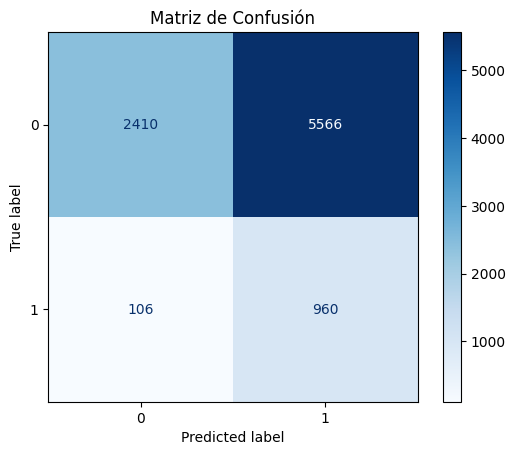

              precision    recall  f1-score   support

           0       0.96      0.30      0.46      7976
           1       0.15      0.90      0.25      1066

    accuracy                           0.37      9042
   macro avg       0.55      0.60      0.36      9042
weighted avg       0.86      0.37      0.44      9042

Verdaderos Negativos (TN): 2410
Falsos Positivos (FP): 5566
Falsos Negativos (FN): 106
Verdaderos Positivos (TP): 960
Ingresos esperados (I): 90708.23 euros


In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month']
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous']

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo con los datos balanceados
# Cálculo de class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds, class_weight=class_weights)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3219 - accuracy: 0.8582 - val_loss: 0.4762 - val_accuracy: 0.8056
Epoch 2/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2512 - accuracy: 0.8975 - val_loss: 0.5010 - val_accuracy: 0.7946
Epoch 3/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2267 - accuracy: 0.9087 - val_loss: 0.4595 - val_accuracy: 0.8143
Epoch 4/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2210 - accuracy: 0.9120 - val_loss: 0.4049 - val_accuracy: 0.8327
Epoch 5/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2136 - accuracy: 0.9159 - val_loss: 0.3947 - val_accuracy: 0.8323
Epoch 6/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2045 - accuracy: 0.9200 - val_loss: 0.4423 - val_accuracy: 0.8287
Epoch 7/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.1998 - a

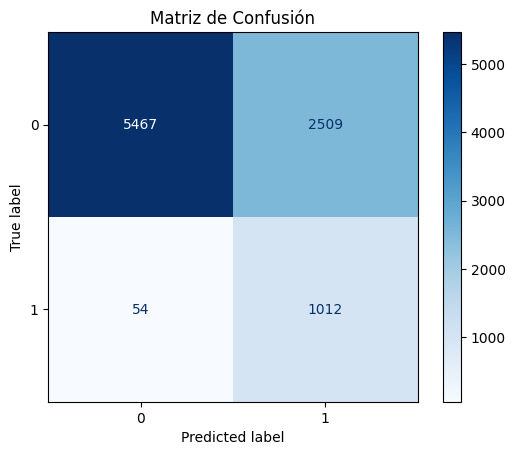

              precision    recall  f1-score   support

           0       0.99      0.69      0.81      7976
           1       0.29      0.95      0.44      1066

    accuracy                           0.72      9042
   macro avg       0.64      0.82      0.63      9042
weighted avg       0.91      0.72      0.77      9042

Verdaderos Negativos (TN): 5467
Falsos Positivos (FP): 2509
Falsos Negativos (FN): 54
Verdaderos Positivos (TP): 1012
Ingresos esperados (I): 102567.55 euros


In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.1).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_01.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3192 - accuracy: 0.8609 - val_loss: 0.5142 - val_accuracy: 0.7949
Epoch 2/50
1245/1245 [==============================] - 1s 956us/step - loss: 0.2491 - accuracy: 0.8984 - val_loss: 0.5389 - val_accuracy: 0.7795
Epoch 3/50
1245/1245 [==============================] - 1s 984us/step - loss: 0.2318 - accuracy: 0.9070 - val_loss: 0.4491 - val_accuracy: 0.8228
Epoch 4/50
1245/1245 [==============================] - 1s 961us/step - loss: 0.2199 - accuracy: 0.9112 - val_loss: 0.4464 - val_accuracy: 0.8145
Epoch 5/50
1245/1245 [==============================] - 1s 946us/step - loss: 0.2118 - accuracy: 0.9171 - val_loss: 0.4031 - val_accuracy: 0.8394
Epoch 6/50
1245/1245 [==============================] - 1s 963us/step - loss: 0.2092 - accuracy: 0.9173 - val_loss: 0.4335 - val_accuracy: 0.8253
Epoch 7/50
1245/1245 [==============================] - 1s 968us/step - loss

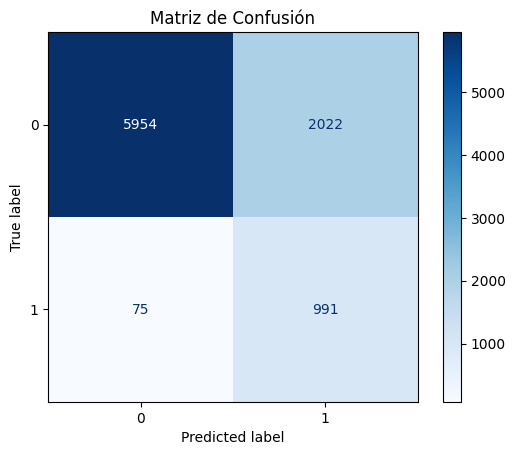

              precision    recall  f1-score   support

           0       0.99      0.75      0.85      7976
           1       0.33      0.93      0.49      1066

    accuracy                           0.77      9042
   macro avg       0.66      0.84      0.67      9042
weighted avg       0.91      0.77      0.81      9042

Verdaderos Negativos (TN): 5954
Falsos Positivos (FP): 2022
Falsos Negativos (FN): 75
Verdaderos Positivos (TP): 991
Ingresos esperados (I): 98204.65 euros


In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.2).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_02.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3227 - accuracy: 0.8591 - val_loss: 0.4735 - val_accuracy: 0.8139
Epoch 2/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2465 - accuracy: 0.8998 - val_loss: 0.5062 - val_accuracy: 0.7954
Epoch 3/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2354 - accuracy: 0.9060 - val_loss: 0.5106 - val_accuracy: 0.7955
Epoch 4/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2226 - accuracy: 0.9123 - val_loss: 0.4179 - val_accuracy: 0.8348
Epoch 5/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2131 - accuracy: 0.9164 - val_loss: 0.4542 - val_accuracy: 0.8188
Epoch 6/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2067 - accuracy: 0.9186 - val_loss: 0.3526 - val_accuracy: 0.8506
Epoch 7/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2033 - a

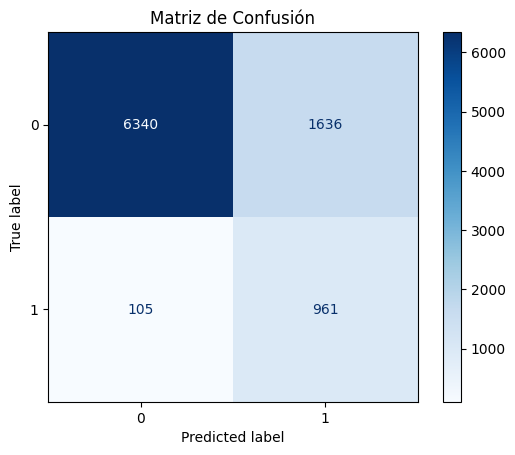

              precision    recall  f1-score   support

           0       0.98      0.79      0.88      7976
           1       0.37      0.90      0.52      1066

    accuracy                           0.81      9042
   macro avg       0.68      0.85      0.70      9042
weighted avg       0.91      0.81      0.84      9042

Verdaderos Negativos (TN): 6340
Falsos Positivos (FP): 1636
Falsos Negativos (FN): 105
Verdaderos Positivos (TP): 961
Ingresos esperados (I): 91895.22 euros


In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.3).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_03.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3251 - accuracy: 0.8573 - val_loss: 0.4579 - val_accuracy: 0.8108
Epoch 2/50
1245/1245 [==============================] - 1s 983us/step - loss: 0.2458 - accuracy: 0.8996 - val_loss: 0.4622 - val_accuracy: 0.8202
Epoch 3/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2309 - accuracy: 0.9080 - val_loss: 0.4323 - val_accuracy: 0.8283
Epoch 4/50
1245/1245 [==============================] - 1s 968us/step - loss: 0.2195 - accuracy: 0.9132 - val_loss: 0.3863 - val_accuracy: 0.8441
Epoch 5/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2131 - accuracy: 0.9168 - val_loss: 0.4544 - val_accuracy: 0.8167
Epoch 6/50
1245/1245 [==============================] - 1s 950us/step - loss: 0.2036 - accuracy: 0.9199 - val_loss: 0.3833 - val_accuracy: 0.8470
Epoch 7/50
1245/1245 [==============================] - 1s 948us/step - loss: 0.

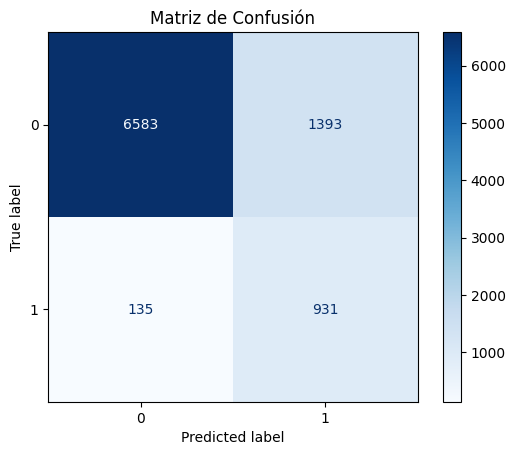

              precision    recall  f1-score   support

           0       0.98      0.83      0.90      7976
           1       0.40      0.87      0.55      1066

    accuracy                           0.83      9042
   macro avg       0.69      0.85      0.72      9042
weighted avg       0.91      0.83      0.86      9042

Verdaderos Negativos (TN): 6583
Falsos Positivos (FP): 1393
Falsos Negativos (FN): 135
Verdaderos Positivos (TP): 931
Ingresos esperados (I): 85550.37 euros


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.4).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_04.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3380 - accuracy: 0.8473 - val_loss: 0.4287 - val_accuracy: 0.8262
Epoch 2/50
1245/1245 [==============================] - 1s 985us/step - loss: 0.2499 - accuracy: 0.8998 - val_loss: 0.4309 - val_accuracy: 0.8323
Epoch 3/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2329 - accuracy: 0.9062 - val_loss: 0.4825 - val_accuracy: 0.8119
Epoch 4/50
1245/1245 [==============================] - 5s 3ms/step - loss: 0.2215 - accuracy: 0.9138 - val_loss: 0.5023 - val_accuracy: 0.8077
Epoch 5/50
1245/1245 [==============================] - 2s 2ms/step - loss: 0.2115 - accuracy: 0.9165 - val_loss: 0.4299 - val_accuracy: 0.8349
Epoch 6/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2045 - accuracy: 0.9200 - val_loss: 0.4079 - val_accuracy: 0.8300
Epoch 7/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2021 -

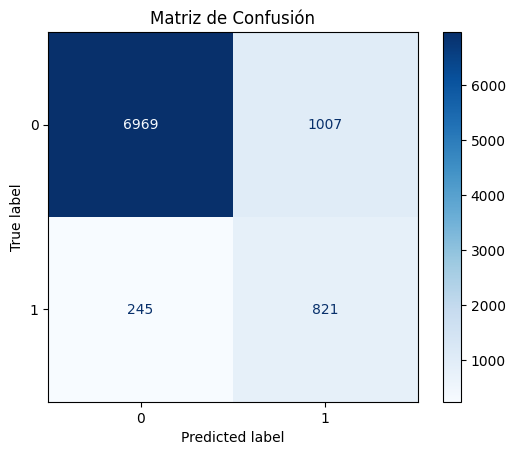

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      7976
           1       0.45      0.77      0.57      1066

    accuracy                           0.86      9042
   macro avg       0.71      0.82      0.74      9042
weighted avg       0.91      0.86      0.88      9042

Verdaderos Negativos (TN): 6969
Falsos Positivos (FP): 1007
Falsos Negativos (FN): 245
Verdaderos Positivos (TP): 821
Ingresos esperados (I): 62160.82 euros


In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_05.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3258 - accuracy: 0.8569 - val_loss: 0.5392 - val_accuracy: 0.7834
Epoch 2/50
1245/1245 [==============================] - 1s 948us/step - loss: 0.2474 - accuracy: 0.9000 - val_loss: 0.4281 - val_accuracy: 0.8322
Epoch 3/50
1245/1245 [==============================] - 1s 981us/step - loss: 0.2315 - accuracy: 0.9067 - val_loss: 0.4561 - val_accuracy: 0.8196
Epoch 4/50
1245/1245 [==============================] - 1s 967us/step - loss: 0.2206 - accuracy: 0.9114 - val_loss: 0.4679 - val_accuracy: 0.8218
Epoch 5/50
1245/1245 [==============================] - 1s 947us/step - loss: 0.2122 - accuracy: 0.9149 - val_loss: 0.4371 - val_accuracy: 0.8192
Epoch 6/50
1245/1245 [==============================] - 1s 958us/step - loss: 0.2064 - accuracy: 0.9194 - val_loss: 0.4603 - val_accuracy: 0.8150
Epoch 7/50
1245/1245 [==============================] - 1s 952us/step - loss

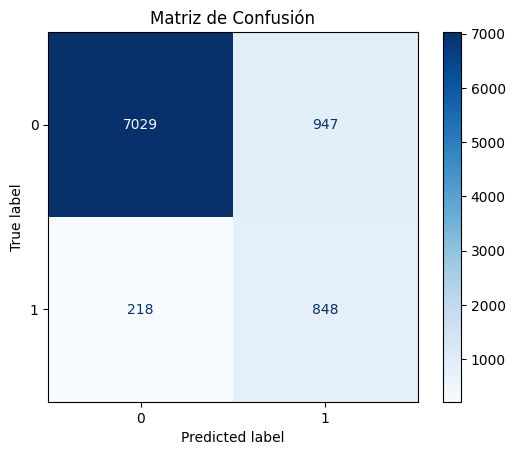

              precision    recall  f1-score   support

           0       0.97      0.88      0.92      7976
           1       0.47      0.80      0.59      1066

    accuracy                           0.87      9042
   macro avg       0.72      0.84      0.76      9042
weighted avg       0.91      0.87      0.88      9042

Verdaderos Negativos (TN): 7029
Falsos Positivos (FP): 947
Falsos Negativos (FN): 218
Verdaderos Positivos (TP): 848
Ingresos esperados (I): 67940.22 euros


In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.6).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_06.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3298 - accuracy: 0.8525 - val_loss: 0.5152 - val_accuracy: 0.7903
Epoch 2/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2490 - accuracy: 0.8983 - val_loss: 0.5059 - val_accuracy: 0.7877
Epoch 3/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2323 - accuracy: 0.9064 - val_loss: 0.4385 - val_accuracy: 0.8344
Epoch 4/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2256 - accuracy: 0.9114 - val_loss: 0.4894 - val_accuracy: 0.8106
Epoch 5/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.2122 - accuracy: 0.9163 - val_loss: 0.4390 - val_accuracy: 0.8178
Epoch 6/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2074 - accuracy: 0.9186 - val_loss: 0.4592 - val_accuracy: 0.8319
Epoch 7/50
1245/1245 [==============================] - 1s 949us/step - loss: 0.1993 -

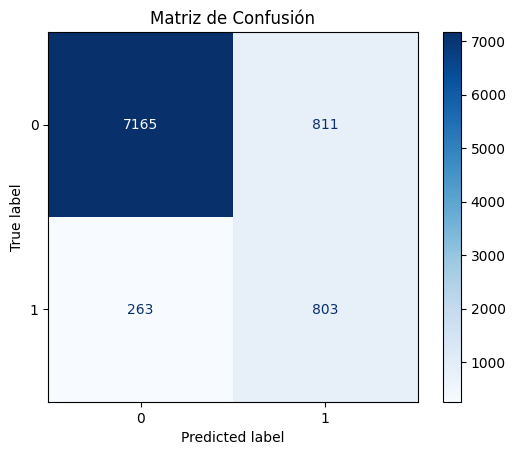

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7976
           1       0.50      0.75      0.60      1066

    accuracy                           0.88      9042
   macro avg       0.73      0.83      0.76      9042
weighted avg       0.91      0.88      0.89      9042

Verdaderos Negativos (TN): 7165
Falsos Positivos (FP): 811
Falsos Negativos (FN): 263
Verdaderos Positivos (TP): 803
Ingresos esperados (I): 58366.34 euros


In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.7).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_07.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3246 - accuracy: 0.8558 - val_loss: 0.5141 - val_accuracy: 0.8018
Epoch 2/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2443 - accuracy: 0.9014 - val_loss: 0.4602 - val_accuracy: 0.8117
Epoch 3/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2312 - accuracy: 0.9084 - val_loss: 0.4978 - val_accuracy: 0.7980
Epoch 4/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2201 - accuracy: 0.9122 - val_loss: 0.4444 - val_accuracy: 0.8161
Epoch 5/50
1245/1245 [==============================] - 1s 983us/step - loss: 0.2103 - accuracy: 0.9170 - val_loss: 0.4307 - val_accuracy: 0.8220
Epoch 6/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2081 - accuracy: 0.9172 - val_loss: 0.4843 - val_accuracy: 0.8032
Epoch 7/50
1245/1245 [==============================] - 1s 977us/step - loss: 0.1993

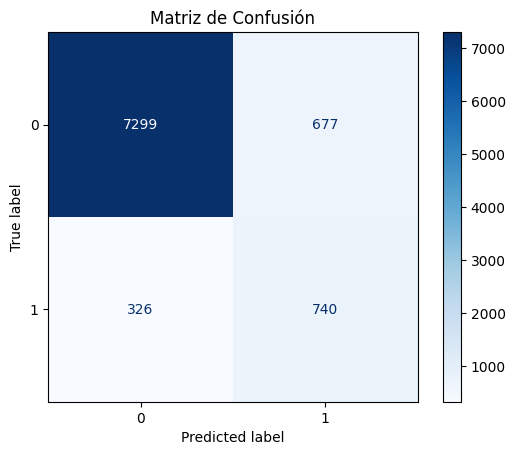

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7976
           1       0.52      0.69      0.60      1066

    accuracy                           0.89      9042
   macro avg       0.74      0.80      0.77      9042
weighted avg       0.91      0.89      0.90      9042

Verdaderos Negativos (TN): 7299
Falsos Positivos (FP): 677
Falsos Negativos (FN): 326
Verdaderos Positivos (TP): 740
Ingresos esperados (I): 44948.94 euros


In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.8).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_08.keras')

y
1    22132
0    17689
Name: count, dtype: int64
Epoch 1/50
1245/1245 [==============================] - 2s 1ms/step - loss: 0.3251 - accuracy: 0.8578 - val_loss: 0.4651 - val_accuracy: 0.8095
Epoch 2/50
1245/1245 [==============================] - 1s 974us/step - loss: 0.2463 - accuracy: 0.9002 - val_loss: 0.4878 - val_accuracy: 0.8032
Epoch 3/50
1245/1245 [==============================] - 1s 975us/step - loss: 0.2289 - accuracy: 0.9078 - val_loss: 0.4140 - val_accuracy: 0.8388
Epoch 4/50
1245/1245 [==============================] - 1s 988us/step - loss: 0.2197 - accuracy: 0.9120 - val_loss: 0.4163 - val_accuracy: 0.8311
Epoch 5/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2119 - accuracy: 0.9173 - val_loss: 0.4429 - val_accuracy: 0.8326
Epoch 6/50
1245/1245 [==============================] - 1s 1ms/step - loss: 0.2042 - accuracy: 0.9193 - val_loss: 0.4083 - val_accuracy: 0.8385
Epoch 7/50
1245/1245 [==============================] - 2s 2ms/step - loss: 0.19

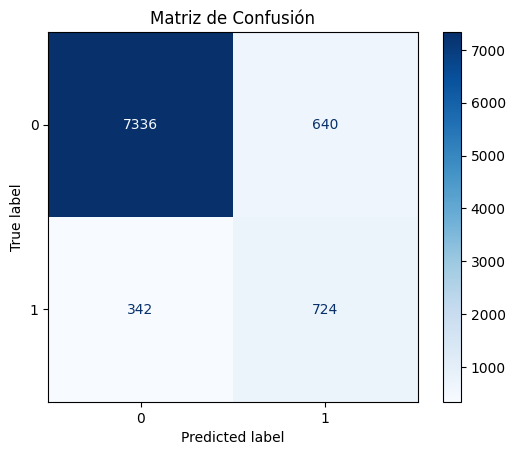

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7976
           1       0.53      0.68      0.60      1066

    accuracy                           0.89      9042
   macro avg       0.74      0.80      0.77      9042
weighted avg       0.91      0.89      0.90      9042

Verdaderos Negativos (TN): 7336
Falsos Positivos (FP): 640
Falsos Negativos (FN): 342
Verdaderos Positivos (TP): 724
Ingresos esperados (I): 41542.08 euros


In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
# Cargar los datos

df = pd.read_csv('bank_data.csv', sep=';')
df.drop(columns=['default', 'loan', 'housing'], inplace=True)

# Convertir las categorías a valores numéricosa
cat_int_feats = ['contact', 'education', 'poutcome', 'marital', 'job', 'month', 'day'] 
cat_str_feats = []  
num_feats = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration'] 

for feat in cat_int_feats:
    df[feat] = df[feat].astype('category').cat.codes

# Convertir la columna objetivo 'y' a 0 y 1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Ordenar columnas
feats_ordered = cat_int_feats + cat_str_feats + num_feats + ['y']
df = df[feats_ordered]

# Dividir los datos en train, validation y test
train = df.sample(frac=0.8, random_state=100)
test = df.drop(train.index)
val = train.sample(frac=0.2, random_state=100)
train = train.drop(val.index)

# Función para convertir DataFrame en dataset de TensorFlow
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("y")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

# Convertir conjuntos de datos a TensorFlow datasets
batch_size = 32
train_ds = dataframe_to_dataset(train)
val_ds = dataframe_to_dataset(val)
test_ds = dataframe_to_dataset(test)

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)
test_ds = test_ds.batch(batch_size)

# SMOTE
X_train = train.drop(columns=['y'])
y_train = train['y']

smote = SMOTEENN(sampling_strategy='auto', random_state=100)

#smote = SMOTE(random_state=100)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Crear nuevo DataFrame 
train_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
train_resampled['y'] = y_resampled

# Verificar el balanceo de las clases
print(train_resampled['y'].value_counts())

# Convertir el nuevo conjunto de datos balanceado a dataset de TensorFlow
train_ds_resampled = dataframe_to_dataset(train_resampled)
train_ds_resampled = train_ds_resampled.batch(batch_size)

# Funciones para codificación de características
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    encoded_feature = normalizer(feature)
    return encoded_feature

def encode_categorical_feature(feature, name, dataset):
    lookup = keras.layers.IntegerLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    encoded_feature = lookup(feature)
    return encoded_feature

# Definir entradas
inputs = []
for i in cat_int_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="int64"))
for i in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=i, dtype="string"))
for i in num_feats:
    inputs.append(keras.Input(shape=(1,), name=i))

# Codificar las características
feats_encoded = []
for i, feat in enumerate(cat_int_feats):
    feats_encoded.append(encode_categorical_feature(inputs[i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(encode_categorical_feature(inputs[len_feats + i], feat, train_ds_resampled))

len_feats = len(feats_encoded)
for i, feat in enumerate(num_feats):
    feats_encoded.append(encode_numerical_feature(inputs[len_feats + i], feat, train_ds_resampled))

# Concatenar todas las características 
all_feats = tf.concat(feats_encoded, axis=1)

# Construir el modelo
model_layers = keras.layers.Dense(128, activation='relu')(all_feats)  
model_layers = keras.layers.Dropout(0.5)(model_layers)  
model_layers = keras.layers.BatchNormalization()(model_layers)  
model_layers = keras.layers.Dense(64, activation='relu')(model_layers) 
model_layers = keras.layers.Dropout(0.5)(model_layers) 
model_layers = keras.layers.BatchNormalization()(model_layers) 
model_layers = keras.layers.Dense(32, activation='relu')(model_layers) 
model_layers = keras.layers.Dense(1, activation='sigmoid')(model_layers) 

model = keras.Model(inputs, model_layers)

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(train_ds_resampled, epochs=50, validation_data=val_ds)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Predicción y evaluación del modelo
y_true = []
y_pred = []
for x, y in test_ds:
    y_true.extend(y.numpy())
    predictions = model.predict(x)
    y_pred.extend((predictions > 0.8).astype(int).flatten())

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print(report)

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Calcular ingresos esperados (I)
I = (P - CC) * tp + (-CC) * fp + CC * tn + (-P) * fn
print(f'Ingresos esperados (I): {I:.2f} euros')

model.save('modeloproy_09.keras')

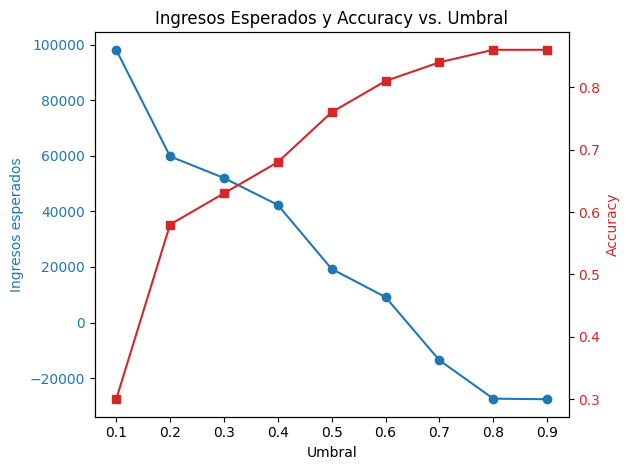

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV
data = pd.read_csv('Umbral.csv')

# Crear la figura y los ejes
fig, ax1 = plt.subplots()

# Crear el gráfico para los Ingresos Esperados
color = 'tab:blue'
ax1.set_xlabel('Umbral')
ax1.set_ylabel('Ingresos esperados', color=color)
ax1.plot(data['Umbral'], data['Ingresos esperados'], color=color, marker='o', label='Ingresos esperados')
ax1.tick_params(axis='y', labelcolor=color)

# Crear un segundo eje para la precisión
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Accuracy', color=color)  
ax2.plot(data['Umbral'], data['Accuracy'], color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Añadir título y leyenda
plt.title('Ingresos Esperados y Accuracy vs. Umbral')
fig.tight_layout()  
plt.show()
